# Построение скоринговой модели

# Окружение

In [ ]:
import json
import os

import matplotlib.pyplot as plt
import mlflow
import mlflow.sklearn
import numpy as np
import pandas as pd
import seaborn as sns
from catboost import CatBoostClassifier
from mlflow.models import evaluate, infer_signature
from sklearn.calibration import calibration_curve
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    brier_score_loss,
    confusion_matrix,
    explained_variance_score,
    f1_score,
    log_loss,
    make_scorer,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from src.config import DATA_RAW, MLFLOW_TRACKING_URI

In [ ]:
mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
mlflow.set_registry_uri(MLFLOW_TRACKING_URI)

In [4]:
pd.options.display.max_columns = 200
pd.options.display.max_rows = 100

# Загрузка датасета

In [ ]:
scoring_dataset = pd.read_excel(DATA_RAW / "scor_TO_SEND.xlsx")
scoring_dataset.head(15)

,f1,f2,f3,f4,f5,f6,f7,f8,f9,f10,f11,f12,f13,f14,f15,f16,f17,f18,f19,f20,f21,f22,f23,f24,target
0,434.0,1076.0,0.383797,1.899742e+05,69480.0,47.0,27.250000,1.989150e+05,0.524176,12.0,0.000000,0.0,NaN,444.0,-0.014167,663210.790000,0.000000,23.0,0.0,0.00,24.0,22.0,1.989150e+05,0.0,0
1,319.0,319.0,2.756571,1.995558e+05,340850.0,22.0,20.750000,2.754617e+05,0.000000,9.0,0.000000,0.0,NaN,461.0,0.000000,162917.000000,0.000000,318.0,0.0,0.00,9.0,24.0,2.754617e+05,0.0,0
2,861.0,2797.0,1.598173,6.359092e+05,745140.0,122.0,27.916667,8.055733e+05,0.536486,12.0,0.172131,29.0,845.0,392.0,0.045476,382284.725000,10.538462,20.0,0.0,242790.06,12.0,30.0,8.055733e+05,1.0,1
3,729.0,2130.0,0.526190,2.058700e+05,123040.0,124.0,27.833333,1.779083e+05,0.677998,12.0,0.169355,26.0,643.0,394.0,0.073921,11312.140000,12.909091,123.0,0.0,10878.94,13.0,30.0,1.779083e+05,0.0,0
4,677.0,1259.0,1.881414,1.091692e+05,156380.0,80.0,26.000000,1.352200e+05,0.394852,10.0,0.000000,0.0,NaN,470.0,-0.014389,0.000000,0.000000,17.0,0.0,0.00,11.0,23.0,1.352200e+05,0.0,0
5,983.0,3222.0,0.885343,1.196783e+06,1130560.0,440.0,27.750000,1.116593e+06,0.936191,11.0,0.018182,5.0,1164.0,326.0,0.323110,182514.702609,1.857143,60.0,0.0,109363.80,11.0,35.0,1.116593e+06,0.0,0
6,635.0,1024.0,2.070913,2.494183e+05,386850.0,54.0,7.333333,3.120350e+05,0.277778,4.0,0.000000,0.0,NaN,455.0,0.277778,30551.000000,0.000000,179.0,0.0,0.00,12.0,22.0,2.003750e+05,0.0,0
7,336.0,1124.0,0.746489,3.425917e+05,196650.0,84.0,27.916667,4.217500e+05,0.365243,12.0,0.023810,8.0,87.0,480.0,0.332006,71428.571429,0.600000,85.0,0.0,83891.56,21.0,22.0,4.217500e+05,0.0,0
8,1058.0,2381.0,1.260355,2.824592e+05,301750.0,73.0,26.750000,3.255017e+05,1.000000,12.0,0.123288,2.0,874.0,389.0,0.000000,138638.970000,1.692308,54.0,0.0,104697.64,12.0,27.0,3.255017e+05,0.0,0
9,426.0,1661.0,1.209862,2.249283e+05,255900.0,88.0,27.666667,2.383450e+05,0.552314,12.0,0.068182,5.0,303.0,411.0,0.493795,236997.111429,4.785714,2.0,0.0,35773.14,12.0,28.0,2.383450e+05,0.0,0


# EDA

## Общий анализ

In [6]:
scoring_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10472 entries, 0 to 10471
Data columns (total 25 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   f1      10354 non-null  float64
 1   f2      10354 non-null  float64
 2   f3      10235 non-null  float64
 3   f4      10235 non-null  float64
 4   f5      10235 non-null  float64
 5   f6      10354 non-null  float64
 6   f7      10235 non-null  float64
 7   f8      10235 non-null  float64
 8   f9      10354 non-null  float64
 9   f10     10235 non-null  float64
 10  f11     10354 non-null  float64
 11  f12     10317 non-null  float64
 12  f13     6395 non-null   float64
 13  f14     10354 non-null  float64
 14  f15     10354 non-null  float64
 15  f16     10130 non-null  float64
 16  f17     10354 non-null  float64
 17  f18     10354 non-null  float64
 18  f19     10354 non-null  float64
 19  f20     10354 non-null  float64
 20  f21     10235 non-null  float64
 21  f22     10354 non-null  float64
 22

In [4]:
scoring_dataset.describe()

,f1,f2,f3,f4,f5,f6,f7,f8,f9,f10,...,f16,f17,f18,f19,f20,f21,f22,f23,f24,target
count,10354.000000,10354.000000,10235.000000,1.023500e+04,1.023500e+04,10354.000000,10235.000000,1.023500e+04,10354.000000,10235.000000,...,1.013000e+04,10354.000000,10354.000000,10354.000000,1.035400e+04,10235.000000,10354.000000,1.023500e+04,10354.000000,10472.000000
mean,1034.013908,2291.781534,1.666818,3.910643e+05,4.237621e+05,120.250241,24.134669,4.244832e+05,0.653688,10.223547,...,2.967405e+05,17.532676,287.288970,1.203013,9.489909e+04,15.472203,36.641491,4.127374e+05,1.556886,0.044691
std,524.705712,1127.941846,7.700781,3.335084e+05,4.476649e+05,79.519186,6.988354,3.623424e+05,0.347187,2.796333,...,4.204639e+05,110.781699,441.067295,5.732227,8.572593e+05,7.946229,10.444026,3.590955e+05,6.210784,0.206634
min,4.000000,4.000000,0.000000,8.333333e+01,1.000000e+02,1.000000,0.000000,0.000000e+00,-0.200000,0.000000,...,0.000000e+00,0.000000,0.000000,0.000000,0.000000e+00,1.000000,20.000000,0.000000e+00,0.000000,0.000000
25%,675.000000,1536.000000,0.754810,1.943725e+05,1.579950e+05,62.000000,24.958333,2.139325e+05,0.407163,10.000000,...,3.996970e+04,0.000000,46.000000,0.000000,0.000000e+00,12.000000,28.000000,2.057925e+05,0.000000,0.000000
50%,1016.000000,2171.000000,1.109835,3.005275e+05,2.883500e+05,106.000000,27.500000,3.244817e+05,0.748548,11.000000,...,1.765434e+05,0.537088,140.000000,0.000000,2.130588e+04,12.000000,35.000000,3.162150e+05,0.000000,0.000000
75%,1307.000000,3049.000000,1.673466,4.584762e+05,5.032750e+05,160.000000,27.916667,4.951175e+05,1.000000,12.000000,...,4.093927e+05,3.653428,339.000000,0.000000,8.651457e+04,17.000000,44.000000,4.848375e+05,0.000000,0.000000
max,5755.000000,8424.000000,558.580645,3.398160e+06,3.000000e+06,745.000000,30.333333,4.156492e+06,1.000000,13.000000,...,1.032830e+07,3312.000000,5755.000000,137.000000,8.226187e+07,170.000000,62.000000,3.964768e+06,157.000000,1.000000


In [ ]:
# Смотрю дисбаланс классов
target = (scoring_dataset["target"] == 1).sum()
print(target, scoring_dataset.shape[0])

468 10472


## Вывод по общему анализу  
Из картины describe и info и по дисбалансу видны выбросы, пропуски и сильный дисбаланс классов. Есть также предпоссылки считать что некоторые признаки можно отнести к категориям.

## Анализ выборочных признаков

# Подготовка датасета

In [ ]:
final_ds = scoring_dataset.copy()
final_ds = final_ds.fillna(final_ds.mean(numeric_only=True))


# Деление на train и test

In [19]:
target = "target"
features = final_ds.drop(columns=target).columns

X = final_ds[features]
y = final_ds[target]

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, shuffle=True, stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    shuffle=True,
    stratify=y_temp,
)

# Pipeline

In [20]:
preprocessor = ColumnTransformer(
    transformers=[("num", StandardScaler(), X_train.columns)],
    remainder="drop",
    n_jobs=-1,
)

# Обучение и логирование

In [ ]:
def train_and_log(
    model,
    X_train,
    X_test,
    y_train,
    y_test,
    RUN_NAME,
    EXPERIMENT_NAME,
    REGISTRY_MODEL_NAME,
    metadata,
    use_eval=True,
):
    """
    Обучает модель, вычисляет метрики, логирует в mlflow.
    """
    # Запускаем обучение модели
    model.fit(X_train, y_train)

    experiment = mlflow.get_experiment_by_name(EXPERIMENT_NAME)

    if experiment is None:
        experiment_id = mlflow.create_experiment(EXPERIMENT_NAME)
    else:
        experiment_id = experiment.experiment_id

    with mlflow.start_run(run_name=RUN_NAME, experiment_id=experiment_id):
        params = {k: str(v) for k, v in model.named_steps["model"].get_params().items()}
        mlflow.log_params(params)

        y_prob = model.predict_proba(X_test)[:, 1]
        y_predict = model.predict(X_test)

        # метрики ранжирования
        auc = roc_auc_score(y_test, y_prob)
        gini = 2 * auc - 1

        # метрики ошибки вероятности (Калибровка)
        brier = brier_score_loss(y_test, y_prob)
        logloss = log_loss(y_test, y_predict) 

        # Бинарные метрики 
        _, err1, _, err2 = confusion_matrix(y_test, y_predict, normalize='all').ravel()
        precision =precision_score(y_test, y_predict)
        recall = recall_score(y_test, y_predict)
        f1 = f1_score(y_test, y_predict)
        
        metrics_to_log = {
            "auc": float(auc),
            "gini": float(gini),
            "brier_score": float(brier),
            "f1": float(f1),
            "precision": float(precision),
            "recall": float(recall),
            "logloss": float(logloss),
            'err1': float(err1),
            'err2': float(err2)
        }
        mlflow.log_metrics(metrics_to_log)

        signature = infer_signature(X_test, y_prob)

        input_example = X_test[:10]
        pip_requirements = "requirements.txt"

        model_info = mlflow.sklearn.log_model(
            sk_model=model,
            name="score_pipeline",
            registered_model_name=REGISTRY_MODEL_NAME,
            metadata=metadata,
            signature=signature,
            input_example=input_example,
            pip_requirements=pip_requirements,
            await_registration_for=60,
        )

        if use_eval:
            eval_data = X_test.copy()
            eval_data["label"] = y_test

            result = evaluate(
                model_info.model_uri,
                eval_data,
                targets="label",
                model_type="classifier",
                evaluator_config={"log_explainer": True},
            )
            for artifact_name in result.artifacts:
                if "shap" in artifact_name.lower():
                    print(f"Generated: {artifact_name}")

        print(f"RUN {RUN_NAME} завершен. Gini: {gini:.4f}")
        return metrics_to_log, y_prob

In [27]:
params_LogisticRegression = {
    "tol": 0.0001,
    "C": 1,
    "random_state": 42,
    "n_jobs": -1,
}

model = LogisticRegression(**params_LogisticRegression)
pipeline = Pipeline(steps=[("preprocessor", preprocessor), ("model", model)])

metadata = {
    "model_type": "classification",
    "model_class": str(model),
    "features": str(features),
    "calibration": "none",
    "notes": "baseline model, with feature selection",
    "status": "experimental",
}
EXPERIMENT_NAME = "credit_scoring_macro_classification"
RUN_NAME = "logistic_regression_baseline"


REGISTRY_MODEL_NAME = "macro_scoring_classifier"

metrics_linear, y_prob_linear = train_and_log(
    model=pipeline,
    X_train=X_train,
    X_test=X_val,
    y_train=y_train,
    y_test=y_val,
    RUN_NAME=RUN_NAME,
    EXPERIMENT_NAME=EXPERIMENT_NAME,
    REGISTRY_MODEL_NAME=REGISTRY_MODEL_NAME,
    metadata=metadata,
    use_eval=False,
)

c:\Users\Салтанат\Documents\Учеба в Яндексе\tests\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\Салтанат\Documents\Учеба в Яндексе\tests\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
2026/04/23 18:28:55 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended sa

Registered model 'macro_scoring_classifier' already exists. Creating a new version of this model...
2026/04/23 18:29:03 INFO mlflow.store.model_registry.abstract_store: Waiting up to 60 seconds for model version to finish creation. Model name: macro_scoring_classifier, version 4
Created version '4' of model 'macro_scoring_classifier'.


RUN logistic_regression_baseline завершен. Gini: 0.4479
🏃 View run logistic_regression_baseline at: http://127.0.0.1:5000/#/experiments/494745118280533175/runs/67840877bc07403d8bf1c9ca7aa3c52c
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/494745118280533175


In [28]:
params_CatBoostClassifier = {}

model = CatBoostClassifier(**params_CatBoostClassifier)

pipeline = Pipeline(steps=[("preprocessor", preprocessor), ("model", model)])


metadata = {
    "model_type": "classification",
    "model_class": str(model),
    "features": str(features),
    "calibration": "none",
    "notes": "baseline model, with feature selection",
    "status": "experimental",
}
EXPERIMENT_NAME = "credit_scoring_macro_classification"

RUN_NAME = "catoost_raw_uncalibrated"

REGISTRY_MODEL_NAME = "macro_scoring_classifier"

metrics_boost, y_prob_boost = train_and_log(
    model=pipeline,
    X_train=X_train,
    X_test=X_val,
    y_train=y_train,
    y_test=y_val,
    RUN_NAME=RUN_NAME,
    EXPERIMENT_NAME=EXPERIMENT_NAME,
    REGISTRY_MODEL_NAME=REGISTRY_MODEL_NAME,
    metadata=metadata,
    use_eval=False,
)

Learning rate set to 0.024118
0:	learn: 0.6576529	total: 28.4ms	remaining: 28.3s
1:	learn: 0.6256156	total: 38.6ms	remaining: 19.3s
2:	learn: 0.5948734	total: 49.4ms	remaining: 16.4s
3:	learn: 0.5670261	total: 58.4ms	remaining: 14.5s
4:	learn: 0.5397955	total: 69.9ms	remaining: 13.9s
5:	learn: 0.5148619	total: 78.9ms	remaining: 13.1s
6:	learn: 0.4914316	total: 88.8ms	remaining: 12.6s
7:	learn: 0.4697204	total: 99ms	remaining: 12.3s
8:	learn: 0.4499774	total: 111ms	remaining: 12.2s
9:	learn: 0.4311599	total: 120ms	remaining: 11.9s
10:	learn: 0.4133111	total: 131ms	remaining: 11.8s
11:	learn: 0.3970971	total: 146ms	remaining: 12s
12:	learn: 0.3818531	total: 162ms	remaining: 12.3s
13:	learn: 0.3679255	total: 174ms	remaining: 12.3s
14:	learn: 0.3549484	total: 195ms	remaining: 12.8s
15:	learn: 0.3427441	total: 214ms	remaining: 13.1s
16:	learn: 0.3316591	total: 228ms	remaining: 13.2s
17:	learn: 0.3201777	total: 243ms	remaining: 13.3s
18:	learn: 0.3103686	total: 260ms	remaining: 13.4s
19:	lea

2026/04/23 18:29:38 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Registered model 'macro_scoring_classifier' already exists. Creating a new version of this model...
2026/04/23 18:29:45 INFO mlflow.store.model_registry.abstract_store: Waiting up to 60 seconds for model version to finish creation. Model name: macro_scoring_classifier, version 5
Created version '5' of model 'macro_scoring_classifier'.


RUN catoost_raw_uncalibrated завершен. Gini: 0.4344
🏃 View run catoost_raw_uncalibrated at: http://127.0.0.1:5000/#/experiments/494745118280533175/runs/16e29ddb905a4080b3926925afec951a
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/494745118280533175


# Метрики

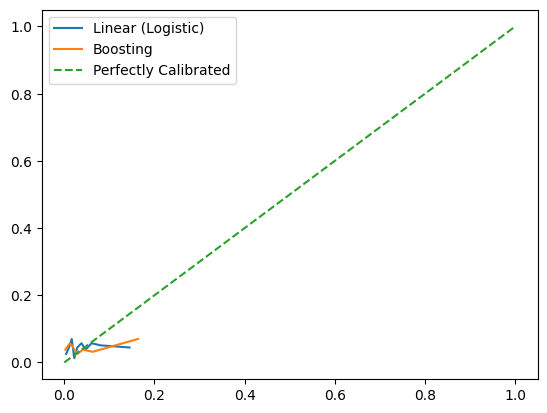

In [29]:
# 3. Строим кривые калибровки
prob_true_lin, prob_pred_lin = calibration_curve(y_test, y_prob_linear, n_bins=10, strategy='quantile')
prob_true_bst, prob_pred_bst = calibration_curve(y_test, y_prob_boost, n_bins=10, strategy='quantile')

plt.plot(prob_pred_lin, prob_true_lin, label='Linear (Logistic)')
plt.plot(prob_pred_bst, prob_true_bst, label='Boosting')
plt.plot([0, 1], [0, 1], linestyle='--', label='Perfectly Calibrated')
plt.legend()
plt.show()

# Проверка на кросс-валидацию

In [ ]:
# 2. Настраиваем стратегию кросс-валидации
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 3. ЗАПУСКАЕМ Кросс-валидацию
# Мы передаем ВЕСЬ pipeline и только ТРЕНИРОВОЧНЫЕ данные
cv_scores = cross_val_score(
    pipeline, 
    X_train, 
    y_train, 
    cv=skf, 
    scoring='roc_auc'
)

print(f"Средний AUC на кросс-валидации: {cv_scores.mean():.4f}")